# Observables: Pair Correlation functions
---

<font size="5"><b>Goal:</b>
At the end of this tutorial, you will know how to measure pair correlation functions using AuxiliaryFields for a lattice models.
</font>

## What you will learn

---

<font size="4">

1. How to set up the HDF5 and json input files to request pair correlation functions
2. how to post process the correlation functions

</font>


## Prerequisites

---

<font size="4">

In this tutorial, we assume that you have already completed all of the basic AuxiliaryFields tutorials, but especially the following tutorials:

1. ...


</font>



&nbsp;



## Introduction.

---

<font size="4">

By pair correlation functions, we mean

$$
P^{\alpha \beta}_{ij} ≡ ⟨ Δ^†_{i,\alpha}Δ_{j,\beta} ⟩,
$$
where  $i,j$ are basis set indices,
$α, β$ are spatial offset indices, and

$$
Δ^†_{i,\alpha} \equiv \frac{1}{\sqrt{2}} \left(c^{\dagger}_{i⇑} c^{†}_{i + e_α ⇓} -  c^{\dagger}_{i⇓} c^{†}_{i + e_α ⇑} \right),
$$

where $e_α$ is the *index offset* associated with the spatial offset.
For example, $e_\alpha$ may correspond to a $+x$ offset.
For convenience, we define,

$$
\bar{i}_α \equiv i + e_\alpha,
$$

such that,

$$
Δ^†_{i,\alpha} \equiv \frac{1}{\sqrt{2}} \left(c^{\dagger}_{i⇑} c^{†}_{\bar{i}_α ⇓} -  c^{\dagger}_{i⇓} c^{†}_{\bar{i}_α ⇑} \right),
$$

and

$$
Δ_{j,\beta} \equiv \frac{1}{\sqrt{2}} \left( c_{\bar{j}_\beta⇓} c_{j ⇑}  - c_{\bar{j}_\beta ⇑} c_{j ⇓} \right),
$$

Using this language, the pair correlation function can be written as,

$$
P^{\alpha \beta}_{ij} ≡ \frac{1}{2} ⟨ \left(c^{\dagger}_{i⇑} c^{†}_{\bar{i}_α ⇓} -  c^{\dagger}_{i⇓} c^{†}_{\bar{i}_α ⇑} \right)  \left( c_{\bar{j}_\beta⇓} c_{j ⇑}  - c_{\bar{j}_\beta ⇑} c_{j ⇓} \right) ⟩.
$$


SAFIRE implements this form of pair correlation function.
It requires a set of $\bar{i}_\alpha = i + e_\alpha$, in the HDF5 input file.
Additionally, specific pairings may be selected in the json input file.
This allows the user to skip some of the offsets saved in the HDF5 file if desired.
We will explore this in more detail below.

</font>

&nbsp;



## Saving index offsets in the HDF5 input
---

The Lattice class from afqmctools can be directly used to find the pairs that we need via the `.get_directed_pairs()` function.
`.get_directed_pairs()` needs a list of "directions", and it will return a dictionary where the keys are the requested directions, and the values are a list of index offsets, $\bar{i}_\alpha [i]$, such that $\bar{i}_{\alpha} [i] = i + e_\alpha$.




computing and storing 1th-nearest neighbors
Computing distance matrix of lattice
Reading lattice site positions from Lattice
computing and storing 1th-nearest image neighbors


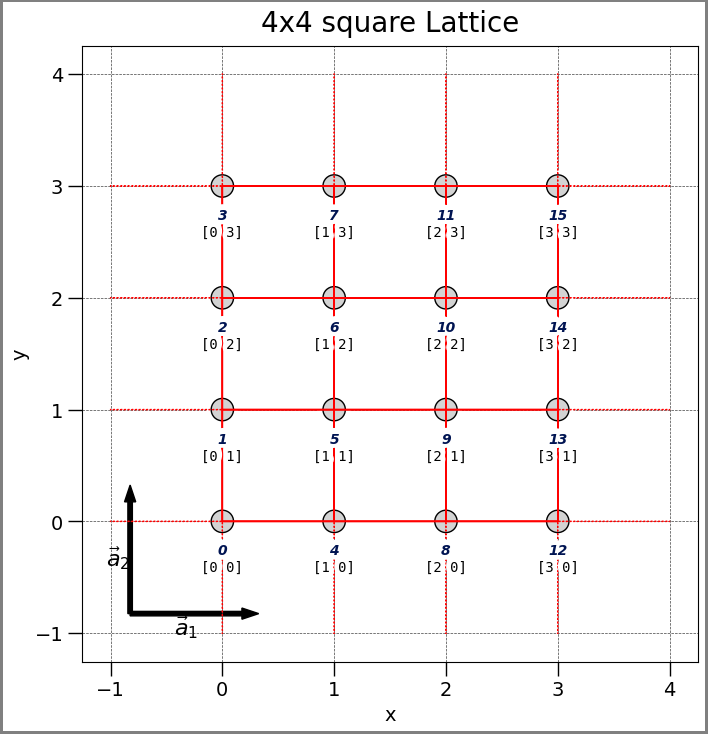

s [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]
+x [np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
-x [np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
+y [np.int64(1), np.int64(2), np.int64(3), np.int64(0), np.int64(5), np.int64(6), np.int64(7), np.int64(4), np.int64(9), np.int64(10), np.int64(11), np.int64(8), np.int64(13), np.int64(14), np.int64(15), np.int64(12)]
-y [np.int64(3), np.int64(0), np.int64(1), np.int64(2), np.int64(7), np.int64(4), np.int64(5), np.int64(6), np.int64(11), np.int6

In [ ]:
from afqmctools.systems.lattice import get_lattice
from afqmctools.utils.visualize import plot_lattice

lattice = get_lattice(
    params=dict(
        L1 = 4,
        L2 = 4,
        boundary1 = "PBC",
        boundary2 = "PBC"
    )
)

# plot the lattice for reality checks!
plot_lattice(lattice)

pairs_dict=lattice.get_directed_pairs(
  directions=["s","+x","-x","+y","-y"]
)

for key,value in pairs_dict.items():
  print(key, value)

<font size="4">
afqmctools also provides a function for saving these pairs to HDF5 in the appropriate format.

```python
from afqmctools.utils.io import write_pair_correlators

write_pair_correlators("afqmc.h5",pair_dict)
```

### Adding Custom Pairings
---

We note that custom pairings can be added by simply inserting a list of offsets with a new key.
For example, we can manually add "+x+y" pairing to the `pairs_dict` dictionary as

```python
pairs_dict["xy"] = [ 5, 6 , 7, 4, 9, 10, 11, 8, 13, 14, 15, 12, 1, 2, 3, 0]
```

As we are about to see, this will allow us to request "xy" pairing by name in the json input file. First, let's add this type of pairing to the dictionary by running the following code block.

</font>

In [ ]:
pairs_dict["xy"] = [ 5, 6 , 7, 4, 9, 10, 11, 8, 13, 14, 15, 12, 1, 2, 3, 0]

for key,value in pairs_dict.items():
  print(key, value)

s [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]
+x [np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
-x [np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
+y [np.int64(1), np.int64(2), np.int64(3), np.int64(0), np.int64(5), np.int64(6), np.int64(7), np.int64(4), np.int64(9), np.int64(10), np.int64(11), np.int64(8), np.int64(13), np.int64(14), np.int64(15), np.int64(12)]
-y [np.int64(3), np.int64(0), np.int64(1), np.int64(2), np.int64(7), np.int64(4), np.int64(5), np.int64(6), np.int64(11), np.int6

## Requesting the pair correlation function in the json input file
---

<font size="4">

The pair correlation function observable may be requested as any other observable within an estimator block.
However, the pair correlation function observable has a few unique parameters that must be set.
They are:

- "filename" which is the name of the HDF5 file where the pairing offsets were saved. These can saved in the same file as the Wavefunciton, and/or Hamiltonian or in their own independent input file. Whichever you prefer.
- "pair_type" is a list of the names of the types of pairing you want to measure. For example, to measure all of the types of pairing that we defined above, we would use `"pair_type" : ["s","+x","-x","+y","-y","xy"]`.

<div class="alert alert-block alert-info">
<b>Note:</b>
  AuxiliaryFields will measure all combinations of pairings that you request.
  i.e. it will compute $P^{\alpha \beta}_{ij}$ where both $\alpha$ and $\beta$ run over the full set of pairing definitions.
</div>

Since the pair correlation functions do not generally comute with the Hamiltonian, we should used a back-propagated estimator.
A back-propagated estimator block with pair correlation functions would look like the following,

```json
"estimator": {
    "name": "back_propagation",
    "path_restoration": true,
    "bp_walker_ortho_interval": 10,
    "nsteps": 200,
    "naverages": 4,
    "equil": 200,
    "pair_correlators" : {
        "name" : "my_pair_correlators",
        "filename" : "afqmc.h5",
        "pair_type" : ["s","+x","-x","+y","-y","xy"]
    }
  }
```

If we decided we only wanted s-wave pair correlatios, we could use

```json
"pair_correlators" : {
  "name" : "my_pair_correlators",
  "filename" : "afqmc.h5",
  "pair_type" : ["s","+x","-x","+y","-y","xy"]
}
```

instead of the above.

</font>


### Full sample input file
---

```json
{
  "afqmc": {
    "project": {
      "id": "qmc",
      "series": 0,
      "mixed_precision": false
    },
    "execute": {
      "walker_set": {
        "walker_type": "NONCOLLINEAR"
      },
      "wavefunction": {
        "filename": "afqmc.h5"
      },
      "timestep": 0.01,
      "steps": 12000,
      "n_walkers_per_mpi_task": 80,
      "accumlate_interval": 10,
      "measure_interval": 10,
      "population_control_interval": 10,
      "walker_ortho_interval": 10,
      "seed": 42,
      "estimator": {
        "name": "back_propagation",
        "path_restoration": true,
        "bp_walker_ortho_interval": 10,
        "nsteps": 200,
        "naverages": 4,
        "equil": 200,
        "pair_correlators" : {
            "name" : "my_pair_correlators",
            "filename" : "afqmc.h5",
            "pair_type" : ["s","+x","-x","+y","-y","xy"]
        }
      }
    }
  }
}
```


## You Turn:
---
Run AuxiliaryFields on a 4x4 Hubbard model with U=4, and $N_{\uparrow}=N_{⇓} = 7$ using the full sample input file above.

## Post-processing pair correlations functions
---


...


In [ ]:
import numpy as np
from warnings import warn

from afqmctools.systems.lattice import get_lattice
from afqmctools.utils.visualize import plot_lattice
from afqmctools.analysis.average import average_pair_correlation


P,dP,correlator_names = average_pair_correlation("qmc.s000.stat.h5")

lattice = get_lattice(
    params={
        'L1' : 4,
        'L2' : 4,
        'boundary1' : "pbc",
        'boundary2' : "pbc"
    }
)

for i in range(len(correlator_names)):
    print(f"correlator name: {correlator_names[i]}")

a = correlator_names.index("s")
b = correlator_names.index("+x")
iav = 3

n_correlators = len(correlator_names)

P_ab_ij = P[iav].reshape(n_correlators,n_correlators,lattice.N_sites,lattice.N_sites)

# take the s, +x correlator
P_s_x_ij = P_ab_ij[a,b,:,:].reshape(lattice.N_sites,lattice.N_sites)
# use the first site as the reference site
P_s_x_0j = P_s_x_ij[0,:].reshape(lattice.L)

plot_lattice(
    lattice,
    density=np.abs(P_s_x_0j.real),
    norm_type="log",
    cmap="plasma"
)

&nbsp;

# Summary

---

&nbsp;

## What you learned

---

<font size="4">

1. How to set up the HDF5 and json input files to request pair correlation functions
2. how to post process the correlation functions

</font>